In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency, f_oneway, chi2


**Hypothesis Test 1**

*Null Hypothesis*: The first pit stop laps are not correlated with the finish position

*Alternative Hypothesis*: The first pit stop laps are correlated with the finish position.

To solve this problem Spearman correlation can be used since pit stop laps and finish positions are ranked structures.  


---

In [ ]:
result_data = pd.read_csv('/content/drive/MyDrive/DSA210/Hypothesis_Test1.csv')
result_data.head(10)

,Unnamed: 0,raceId,year,round,circuitId,name,date,time,resultId,driverId,...,points,laps,fastestLap,rank,fastestLapTime,statusId,stop,lap,duration,milliseconds
0,0,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27184,830,...,25.0,50,50,1,1:33.365,1,1,25,21.708,0 days 00:00:00.000021708
1,1,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27185,847,...,18.0,50,50,9,1:34.592,1,1,17,20.929,0 days 00:00:00.000020929
2,2,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27186,863,...,15.0,50,48,2,1:33.998,1,1,2,21.968,0 days 00:00:00.000021968
3,3,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27187,844,...,12.0,50,43,3,1:34.304,1,1,24,21.351,0 days 00:00:00.000021351
4,4,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27188,832,...,10.0,50,42,4,1:34.496,1,1,22,21.164,0 days 00:00:00.000021164
5,5,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27189,865,...,8.0,50,50,10,1:34.620,1,1,20,21.324,0 days 00:00:00.000021324
6,6,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27190,807,...,6.0,50,49,8,1:34.592,1,1,30,22.333,0 days 00:00:00.000022333
7,7,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27191,1,...,4.0,50,49,6,1:34.553,1,1,29,21.638,0 days 00:00:00.000021638
8,8,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27192,839,...,2.0,50,48,7,1:34.557,1,1,27,22.389,0 days 00:00:00.000022389
9,9,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27193,860,...,1.0,50,50,5,1:34.519,1,1,17,21.491,0 days 00:00:00.000021491


In [ ]:
hyp1 = result_data[['positionOrder', 'lap']]
hyp1.head(10)

,positionOrder,lap
0,1,25
1,2,17
2,3,2
3,4,24
4,5,22
5,6,20
6,7,30
7,8,29
8,9,27
9,10,17


**Results**

---

In [ ]:
res = stats.spearmanr(hyp1['lap'], hyp1['positionOrder'])
print("P Value: ", res.pvalue)
print("Correlation: ", res.correlation)


P Value:  7.911089255470108e-25
Correlation:  -0.12801623375708424


**Analysis of the Results**

From these results it can be seen that p value is significantly lower than 0.05 therefore we can safely reject the null hypothesis. However, there is not a strong correlation between the first pit stop laps and finish position.

---

In [ ]:
hyp1['lap'].unique()

array([25, 17,  2, 24, 22, 20, 30, 29, 27, 16,  1, 13, 21, 12, 10,  9, 11,
       14,  4,  3, 15, 26, 28, 23, 32, 36, 19, 45, 18, 37, 39, 42, 33, 31,
        5, 40, 41, 34,  7,  8, 35, 53, 38, 50, 49,  6, 43, 48, 44, 46, 47,
       52, 51, 55, 57, 56, 69, 54, 58, 64])

**Analyses of the Graph**

This graph can be used for seeing the results more clearly. In this graph first pit lap of 15 or lower is considered early stop. Laps between 15 and 30 are considered the normal window and laps after 30 are considered the late window.


From the graph it can be seen that it is possible to win the race from all pit windows. However the median value of the normal window is sligtly better compared to the rest.

Also, pitting in the early or normal laps could result in more varying results and has a higher difference of Q3 and Q1 compared to the late pitters.  

---

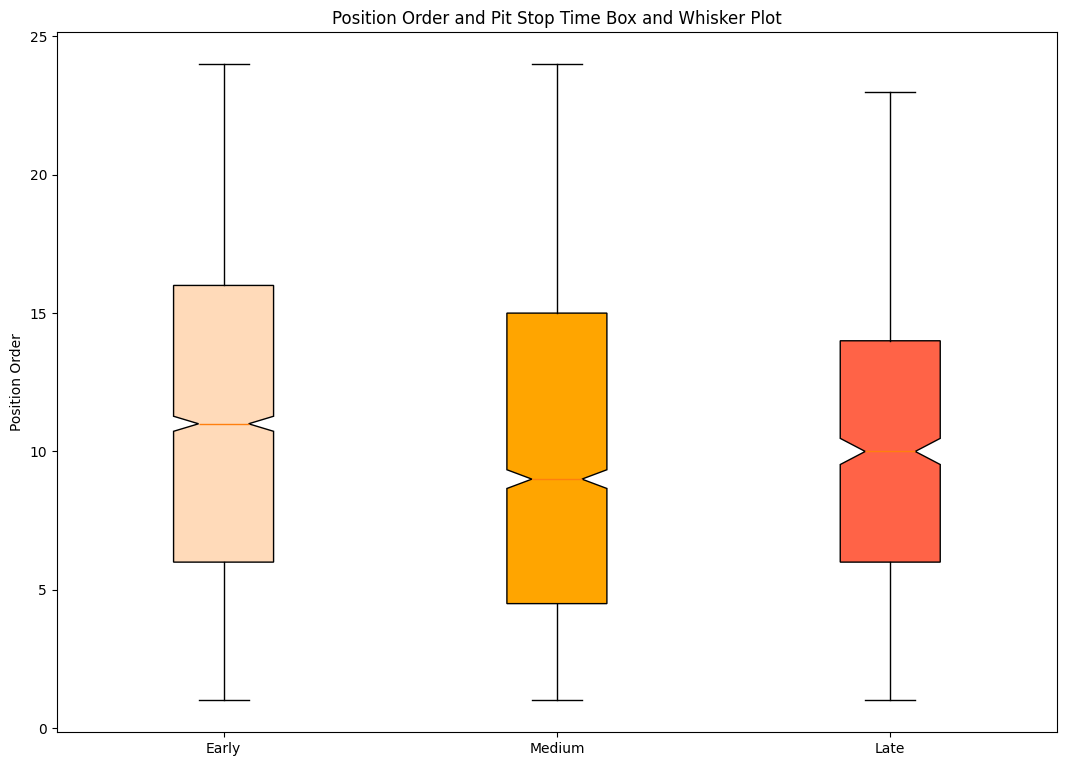

In [ ]:
early_subset = hyp1[hyp1['lap'] <= 15]
normal_subset = hyp1[(hyp1['lap'] > 15) & (hyp1['lap'] <= 30)]
late_subset = hyp1[hyp1['lap'] > 30]
labels = ['Early', 'Medium', 'Late']
colors = ['peachpuff', 'orange', 'tomato']
subset = [early_subset['positionOrder'], normal_subset['positionOrder'], late_subset['positionOrder']]
fig = plt.figure(figsize =(10, 7))
ax = fig.add_axes([0, 0, 1, 1])
ax.set_ylabel('Position Order')
ax.set_title('Position Order and Pit Stop Time Box and Whisker Plot')
bp = ax.boxplot(subset, patch_artist=True, tick_labels=labels, notch=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
plt.show()

**Hypothesis Test 2**

*Null Hypothesis*: The track temprature is not correlated with the number of pitstops.

*Alternative Hypothesis*: The track temprature is correlated with the number of pitstops.

To test this alternative hypothesis I converted track tempratures and number of pitstops to rank because Spearman allows non-linear relationship.

---

In [ ]:
result_data1 = pd.read_csv('/content/drive/MyDrive/DSA210/Hypothesis_Test2.csv')
result_data1.head(10)

,Unnamed: 0,raceId,stop,year,round,circuitId,name_x,date,time,circuitRef,location,country,lat,lng,alt,temp,stop_rank,temp_rank
0,0,337,1.095238,2010,1,3,Bahrain Grand Prix,2010-03-14,12:00:00,bahrain,Sakhir,Bahrain,26.03250,50.51060,7,26.1,18.0,258.5
1,1,338,1.428571,2010,2,1,Australian Grand Prix,2010-03-28,6:00:00,albert_park,Melbourne,Australia,-37.84970,144.96800,10,21.8,123.5,189.5
2,2,339,1.150000,2010,3,2,Malaysian Grand Prix,2010-04-04,8:00:00,sepang,Sepang,Malaysia,2.76083,101.73800,18,29.9,39.0,297.0
3,3,340,2.567164,2010,4,17,Chinese Grand Prix,2010-04-18,6:00:00,shanghai,Shanghai,China,31.33890,121.22000,5,17.3,293.0,98.5
4,4,341,1.250000,2010,5,4,Spanish Grand Prix,2010-05-09,12:00:00,catalunya,Montmeló,Spain,41.57000,2.26111,109,15.1,72.5,45.0
5,5,342,1.050000,2010,6,6,Monaco Grand Prix,2010-05-16,12:00:00,monaco,Monte Carlo,Monaco,43.73470,7.42056,7,16.2,6.5,68.5
6,6,343,1.185185,2010,7,5,Turkish Grand Prix,2010-05-30,11:00:00,istanbul,Istanbul,Turkey,40.95170,29.40500,130,22.8,47.0,214.0
7,7,344,2.000000,2010,8,7,Canadian Grand Prix,2010-06-13,16:00:00,villeneuve,Montreal,Canada,45.50000,-73.52280,13,18.9,258.5,138.0
8,8,347,1.310345,2010,11,10,German Grand Prix,2010-07-25,12:00:00,hockenheimring,Hockenheim,Germany,49.32780,8.56583,103,16.6,93.5,79.0
9,9,348,1.120000,2010,12,11,Hungarian Grand Prix,2010-08-01,12:00:00,hungaroring,Budapest,Hungary,47.57890,19.24860,264,22.9,26.0,215.0


**Results**

---

In [ ]:
res = stats.spearmanr(result_data1['temp_rank'], result_data1['stop_rank'])
print("P Value: ", res.pvalue)
print("Correlation: ", res.correlation)

P Value:  0.4264388306436038
Correlation:  -0.046084672464115836


**Analysis of the Results**

Since the p-value is high and the correlation does not exist, the null hypothesis can't be rejected. Since both of these values were unsuitable I wanted to check whether the relationship was monotonic.


---

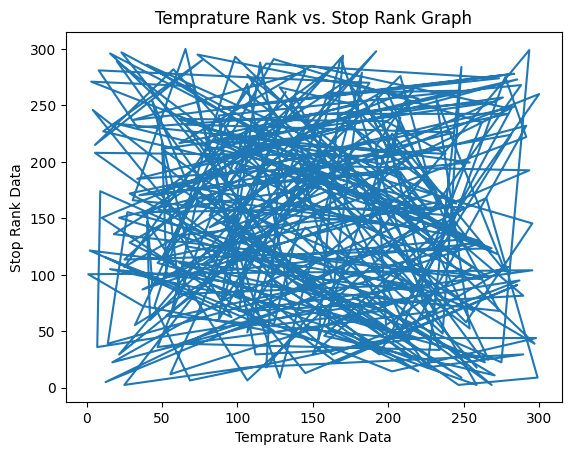

In [ ]:
plt.plot(result_data1['temp_rank'], result_data1['stop_rank'])
plt.xlabel("Temprature Rank Data")
plt.ylabel("Stop Rank Data")
plt.title("Temprature Rank vs. Stop Rank Graph")
plt.show()

**Graph Analysis**

From the graph it can be seen that, the relationship is not monotonic. Actually there is not any relationship between these variables.

---

**Hypothesis Test 3**

*Null Hypothesis:* Fastest Laps are independent of winning races.

*Alternative Hypothesis*: Drivers setting the fastest lap have better chance of winning the races.

To check this hypothesis Chi-Square distribution will be used where the counts of 4 different cases will be calculated:



1.   Winning the race and having the fastest lap.
2.   Winning the race but not having the fastest lap.
3.   Not winning the race but having the fastest lap.
4.   Not winning the race and not having the fastest lap.



---

In [ ]:
result_data2 = pd.read_csv('/content/drive/MyDrive/DSA210/Hypothesis_Test3.csv')
result_data2.head(10)

,Unnamed: 0,raceId,driverId,positionOrder,rank
0,0,1166,830,1,1
1,1,1166,847,2,9
2,2,1166,863,3,2
3,3,1166,844,4,3
4,4,1166,832,5,4
5,5,1166,865,6,10
6,6,1166,807,7,8
7,7,1166,1,8,6
8,8,1166,839,9,7
9,9,1166,860,10,5


In [ ]:
rank_1_order_1 = len(result_data2[(result_data2['rank'] == 1) & (result_data2['positionOrder'] == 1)])
rank_not_1_order_1 = len(result_data2[(result_data2['rank'] != 1) & (result_data2['positionOrder'] == 1)])
rank_1_order_not_1 = len(result_data2[(result_data2['rank'] == 1) & (result_data2['positionOrder'] != 1)])
rank_not_1_order_not_1 = len(result_data2[(result_data2['rank'] != 1) & (result_data2['positionOrder'] != 1)])
total = len(result_data2)
if(total == rank_1_order_1 + rank_not_1_order_1 + rank_1_order_not_1 + rank_not_1_order_not_1):
  print("Sizes are equal.")

Sizes are equal.


Create an table for chi-square where the rows represent the fastest lap or not and columns represent finishing first or not.

---


In [ ]:
table = np.array([[rank_1_order_1, rank_1_order_not_1], [rank_not_1_order_1, rank_not_1_order_not_1]])
table_df = pd.DataFrame(table, index=['Rank 1 Count', 'Not Rank 1 Count'], columns=['Order 1 Count', 'Not Order 1 Count'])
print("Actual Values \n")
print(table_df)

Actual Values 

                  Order 1 Count  Not Order 1 Count
Rank 1 Count                 95                231
Not Rank 1 Count            233               6336


**Results**

---

In [ ]:
res1 = chi2_contingency(table)
print("P Value: ", res1.pvalue)

P Value:  1.9549296903538364e-98


**Analysis of the Results**

Since this p-value is significantly lower than 0.05, we can safely reject the null hypothesis.

---

The following table gives the expected values:

In [ ]:
table_df1 = pd.DataFrame(res1.expected_freq, index=['Rank 1 Count', 'Not Rank 1 Count'], columns=['Order 1 Count', 'Not Order 1 Count'])
print(table_df1)

                  Order 1 Count  Not Order 1 Count
Rank 1 Count          15.508049         310.491951
Not Rank 1 Count     312.491951        6256.508049


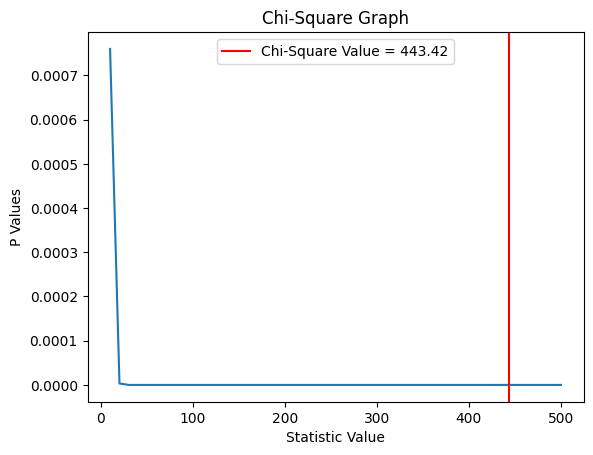

In [ ]:
dof = res1.dof
val = res1.statistic
x = np.linspace(0, 500, 50)
pdf = chi2.pdf(x, dof)
plt.plot(x, pdf)
plt.xlabel('Statistic Value')
plt.ylabel('P Values')
plt.title("Chi-Square Graph")
plt.axvline(x = val, color='r', label = f'Chi-Square Value = {round(val, 2)}')
plt.legend()
plt.show()

**Hypothesis Test 4**

*Null Hypothesis*: The mean number of pitstops is equal for all types of tracks.

*Alternative Hypothesis*: At least one track type has different mean number of pitstops.

To check this hypothesis test ANOVA can be applied since there are three types of tracks.

---


In [ ]:
result_data3 = pd.read_csv('/content/drive/MyDrive/DSA210/Hypothesis_Test4.csv')
result_data3['Circuit Type'].unique()

array(['Street', 'Race', 'Road'], dtype=object)

In [ ]:
result_data3.head(5)

,Unnamed: 0,raceId,year,round,circuitId,name_x,date,time,circuitRef,location,...,lat,lng,alt,temp,stop,Circuit,Track Length (km),Turns,Direction,Circuit Type
0,0,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,...,36.1147,-115.1730,642,14.2,1.217391,Las Vegas Street Circuit,6.201,17,Anti clockwise,Street
1,1,1142,2024,22,80,Las Vegas Grand Prix,2024-11-23,6:00:00,vegas,Las Vegas,...,36.1147,-115.1730,642,14.6,1.538462,Las Vegas Street Circuit,6.201,17,Anti clockwise,Street
2,2,1119,2023,21,80,Las Vegas Grand Prix,2023-11-19,6:00:00,vegas,Las Vegas,...,36.1147,-115.1730,642,17.2,1.387097,Las Vegas Street Circuit,6.201,17,Anti clockwise,Street
3,3,1150,2025,6,79,Miami Grand Prix,2025-05-04,20:00:00,miami,Miami Gardens,...,25.9581,-80.2389,0,24.9,1.000000,Miami International Autodrome,5.412,19,Anti clockwise,Street
4,4,1126,2024,6,79,Miami Grand Prix,2024-05-05,20:00:00,miami,Miami Gardens,...,25.9581,-80.2389,0,26.4,1.321429,Miami International Autodrome,5.412,19,Anti clockwise,Street


In [ ]:
street_race = result_data3[result_data3['Circuit Type'] == 'Street']
street_race = street_race[['Circuit Type', 'stop']]

race_race = result_data3[result_data3['Circuit Type'] == 'Race']
race_race = race_race[['Circuit Type', 'stop']]

road_race = result_data3[result_data3['Circuit Type'] == 'Road']
road_race = road_race[['Circuit Type', 'stop']]


**Results**

Since the p-value is lower than 0.05, we can safely say that the null hypothesis is rejected.

---

In [ ]:
res2 = f_oneway(street_race['stop'], race_race['stop'], road_race['stop'])
print("P Value: ", res2.pvalue)

P Value:  0.019112248978174238


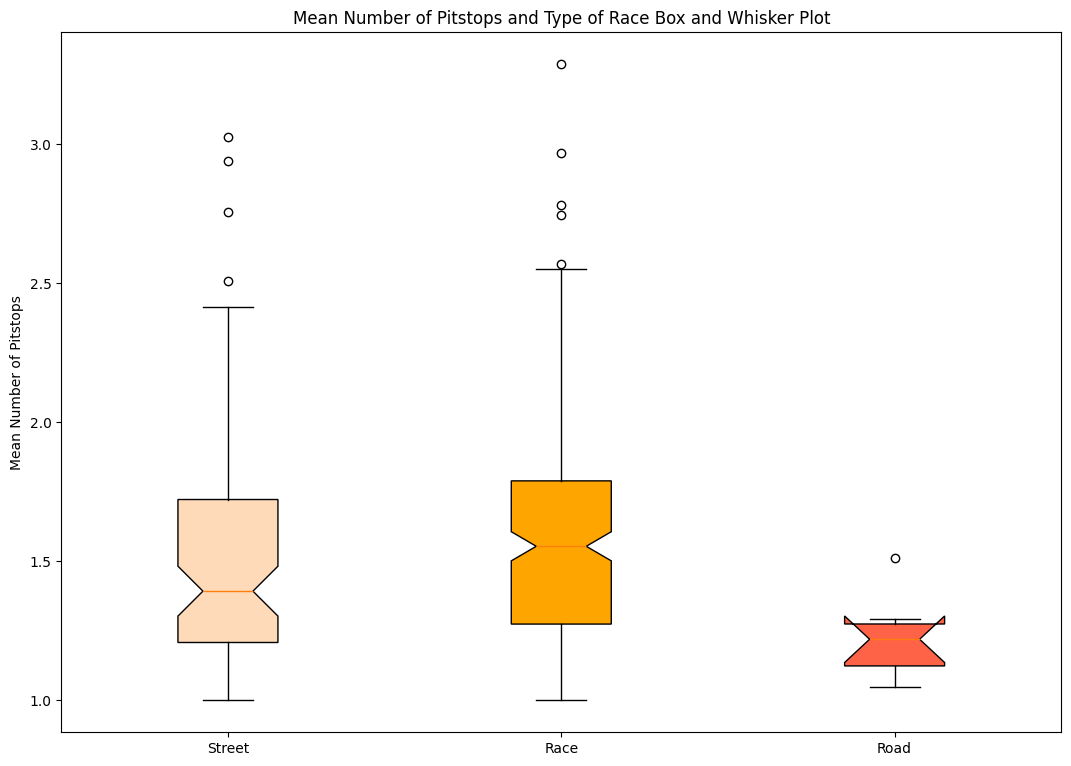

In [ ]:
labels = ['Street', 'Race', 'Road']
subset = [street_race['stop'], race_race['stop'], road_race['stop']]

fig = plt.figure(figsize =(10, 7))
ax = fig.add_axes([0, 0, 1, 1])
ax.set_ylabel('Mean Number of Pitstops')
ax.set_title('Mean Number of Pitstops and Type of Race Box and Whisker Plot')
bp = ax.boxplot(subset, patch_artist=True, tick_labels=labels, notch=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
plt.show()